# 1. Exploratory Data Analysis (EDA) Setup & Data Loading
In this first cell, we will import all the necessary foundational libraries for data manipulation and visualization. We will also directly load the **Auto MPG** dataset using Seaborn's built-in dataset repository, which pulls clean, standardized data directly from the online source.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Auto MPG dataset
df = sns.load_dataset('mpg')

# Display the first few rows to confirm successful loading
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


# 2. Initial Data Inspection & Structural Overview
Before plotting or modeling, it is critical to understand the data types, dimensions, and statistical summaries of our dataset.

In [5]:
print("--- DATASET INFORMATION ---")
df.info()

print("\n--- STATISTICAL SUMMARY ---")
display(df.describe())

--- DATASET INFORMATION ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB

--- STATISTICAL SUMMARY ---


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


# 3. Missing Value Imputation
From the inspection above, you should notice that the `horsepower` column contains a few missing values (NaN).

In [6]:
# Check how many missing values exist
missing_hp = df['horsepower'].isnull().sum()
print(f"Missing values in horsepower before imputation: {missing_hp}")

# Impute missing values with the median
median_hp = df['horsepower'].median()
df['horsepower'].fillna(median_hp, inplace=True)

# Verify imputation
print(f"Missing values after imputation: {df['horsepower'].isnull().sum()}")

Missing values in horsepower before imputation: 6
Missing values after imputation: 0


/tmp/ipykernel_67/3161706786.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['horsepower'].fillna(median_hp, inplace=True)


# 4. Univariate Analysis: Target Variable Distribution
We need to understand the distribution of our target variable: `mpg`. We will plot a histogram to observe whether the fuel efficiency is normally distributed, skewed, or multimodal. 

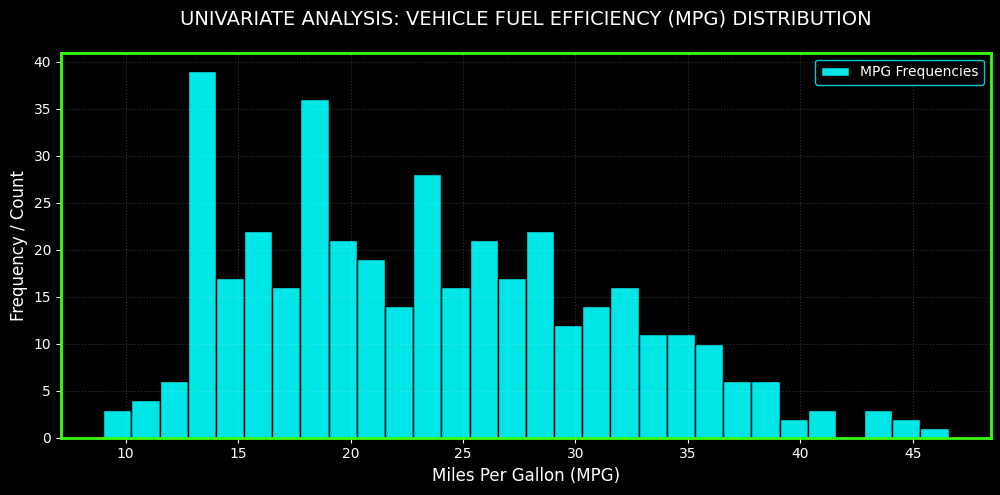

In [7]:
plt.figure(figsize=(12, 5), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')

# Plot the distribution
sns.histplot(df['mpg'], color='#00FFFF', bins=30, alpha=0.9, edgecolor='black', ax=ax, label='MPG Frequencies')

# AXIS STYLING
plt.title("UNIVARIATE ANALYSIS: VEHICLE FUEL EFFICIENCY (MPG) DISTRIBUTION", color='white', fontsize=14, pad=20)
plt.xlabel("Miles Per Gallon (MPG)", color='white', fontsize=12)
plt.ylabel("Frequency / Count", color='white', fontsize=12)
ax.tick_params(axis='both', colors='white', labelsize=10)

for spine in ax.spines.values():
    spine.set_color('#39FF14') # Neon Green frame
    spine.set_linewidth(2)

plt.legend(facecolor='black', labelcolor='white', edgecolor='#00FFFF')
plt.grid(True, linestyle=':', alpha=0.2, color='white')
plt.show()

# 5. Bivariate Analysis: Feature vs. Target Relationship
To evaluate how well a Linear Regression or Polynomial Regression model might perform, we should look at the 2D relationship between a primary physical feature (like vehicle `weight`) and our target (`mpg`). This scatter plot will reveal whether the relationship is strictly linear or if it follows a non-linear trajectory.

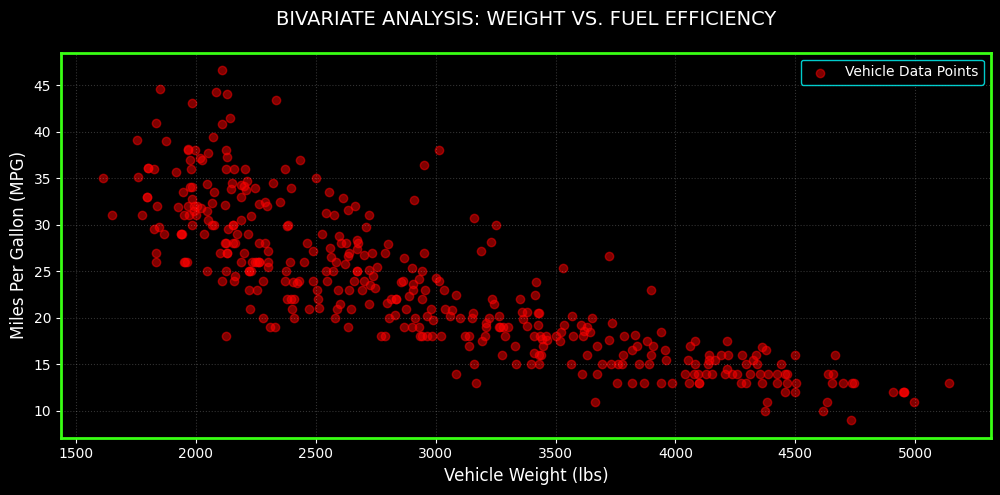

In [2]:
plt.figure(figsize=(12, 5), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')

# Plot Weight vs MPG
plt.scatter(df['weight'], df['mpg'], color='#FF0000', alpha=0.5, label='Vehicle Data Points')

# AXIS STYLING
plt.title("BIVARIATE ANALYSIS: WEIGHT VS. FUEL EFFICIENCY", color='white', fontsize=14, pad=20)
plt.xlabel("Vehicle Weight (lbs)", color='white', fontsize=12)
plt.ylabel("Miles Per Gallon (MPG)", color='white', fontsize=12)
ax.tick_params(axis='both', colors='white', labelsize=10)

for spine in ax.spines.values():
    spine.set_color('#39FF14') # Neon Green frame
    spine.set_linewidth(2)

plt.legend(facecolor='black', labelcolor='white', edgecolor='#00FFFF')
plt.grid(True, linestyle=':', alpha=0.2, color='white')
plt.show()

# 6. Multivariate Analysis: Feature Correlation & Multicollinearity
Regularized models like Ridge, Lasso, and Elastic Net were introduced to handle multicollinearity. Here, we calculate and visualize the Pearson correlation coefficient between all numerical variables. If features like `weight`, `displacement`, and `cylinders` have high correlation scores (close to 1.0 or -1.0) with each other, it proves the necessity of those regularized algorithms!

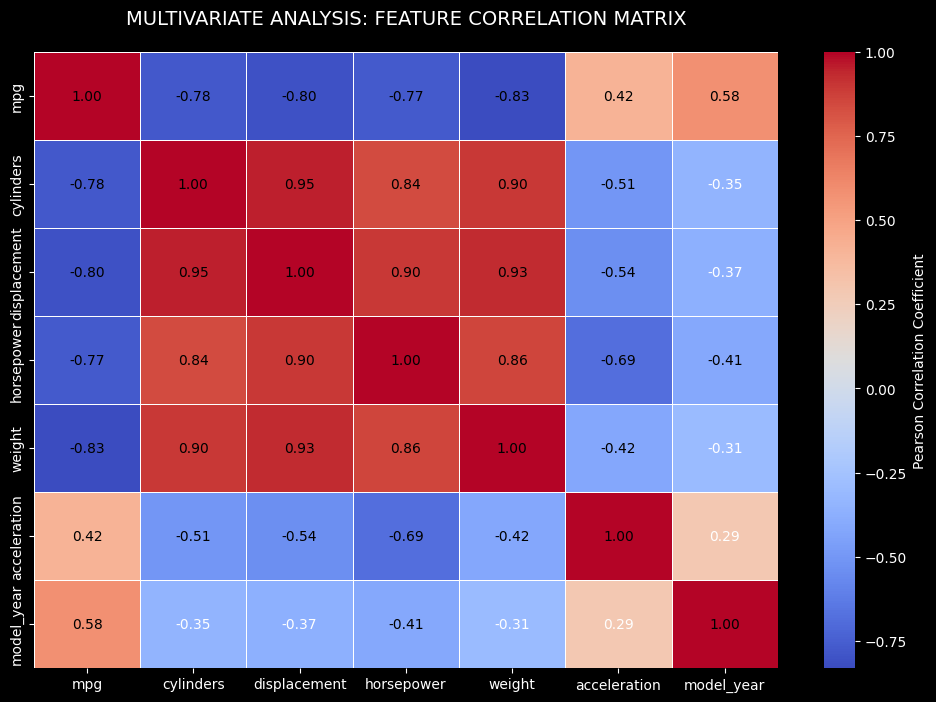

In [9]:
plt.figure(figsize=(12, 8), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')

# Isolate numeric columns only for correlation math
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

# Create Heatmap
heatmap = sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5,
                      ax=ax, cbar_kws={'label': 'Pearson Correlation Coefficient'})

# Adjust Colorbar Text to fit the dark theme
cbar = heatmap.collections[0].colorbar
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')
cbar.set_label('Pearson Correlation Coefficient', color='white')

# Adjust annotations inside the heatmap to be visible
for text in ax.texts:
    text.set_color("black" if abs(float(text.get_text())) > 0.4 else "white")

# AXIS STYLING
plt.title("MULTIVARIATE ANALYSIS: FEATURE CORRELATION MATRIX", color='white', fontsize=14, pad=20)
ax.tick_params(axis='both', colors='white', labelsize=10)

for spine in ax.spines.values():
    spine.set_color('#39FF14') # Neon Green frame
    spine.set_linewidth(2)

plt.show()